## Instalación de librerias

In [24]:
'''
!pip install yfinance
!pip install bs4
!pip install nbformat
!pip install matplotlib
'''

'\n!pip install yfinance\n!pip install bs4\n!pip install nbformat\n!pip install matplotlib\n'

## Importación de librerias

In [25]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup

## Función para generar las gráficas

In [26]:
import matplotlib.pyplot as plt

def make_graph(stock_data, revenue_data, stock):
    """
    Crea un gráfico comparativo de dos paneles: Precio de la acción y Ingresos.
    
    Argumentos:
    stock_data: DataFrame con columnas 'Date' y 'Close'.
    revenue_data: DataFrame con columnas 'Date' y 'Revenue'.
    stock: String con el nombre de la empresa (ej. 'Tesla').
    """
    
    # 1. Filtrado de datos para acotar el periodo de tiempo visualizado
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    # 2. Configuración de la figura con dos subgráficos (filas=2, columnas=1)
    # sharex=True permite que ambos gráficos compartan el mismo eje de fechas
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # --- Subgráfico 1: Precio de la Acción ---
    # Convertimos Date a datetime para asegurar el orden cronológico y Close a float para cálculos
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), 
                 stock_data_specific.Close.astype("float"), 
                 label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # --- Subgráfico 2: Ingresos (Revenue) ---
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), 
                 revenue_data_specific.Revenue.astype("float"), 
                 label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    # Ajuste automático de espacio entre elementos y visualización
    plt.tight_layout()
    plt.show()

## TESLA

In [27]:
## Se realiza la extracción de la información de TESLA
# 1. Creamos un objeto Ticker para Tesla
# Esto permite acceder a todos los métodos de la API de Yahoo Finance para este símbolo
TSLA = yf.Ticker('TSLA')

# 2. Extraemos el historial de precios de la acción
# 'period=max' descarga toda la información histórica disponible desde la salida a bolsa
tesla_data = TSLA.history(period='max')

# 3. Limpieza del índice
# Por defecto, yfinance usa la fecha ('Date') como índice. 
# reset_index la convierte en una columna normal para facilitar su manipulación y graficado.
tesla_data.reset_index(inplace=True)

# 4. Visualización preliminar
# Muestra las primeras 5 filas para verificar que los datos se descargaron correctamente
print(tesla_data.head())

                       Date      Open      High       Low     Close  \
0 2010-06-29 00:00:00-04:00  1.266667  1.666667  1.169333  1.592667   
1 2010-06-30 00:00:00-04:00  1.719333  2.028000  1.553333  1.588667   
2 2010-07-01 00:00:00-04:00  1.666667  1.728000  1.351333  1.464000   
3 2010-07-02 00:00:00-04:00  1.533333  1.540000  1.247333  1.280000   
4 2010-07-06 00:00:00-04:00  1.333333  1.333333  1.055333  1.074000   

      Volume  Dividends  Stock Splits  
0  281494500        0.0           0.0  
1  257806500        0.0           0.0  
2  123282000        0.0           0.0  
3   77097000        0.0           0.0  
4  103003500        0.0           0.0  


## Web Scraping de TESLA

In [28]:

# 1. Definir la URL de origen
# Esta URL apunta a un archivo HTML estático que contiene los datos financieros (ingresos) de la empresa.
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm'

# 2. Enviar la solicitud HTTP GET
# Usamos la librería 'requests' para descargar el contenido de la página. 
# El objeto 'html_data' contendrá la respuesta del servidor (incluyendo el código HTML).
html_data = requests.get(url)

# 3. Parsear el contenido HTML
# Creamos un objeto 'soup' usando BeautifulSoup. 
# 'html.parser' es el analizador interno de Python que organiza el texto plano en una 
# estructura de árbol jerárquica para que sea fácil buscar etiquetas y clases.
soup = BeautifulSoup(html_data.text, 'html.parser')

# Verificamos si la descarga fue exitosa (Código 200)
if html_data.status_code == 200:
    print("Página descargada y parseada correctamente")

Página descargada y parseada correctamente


In [29]:
# 1. Localizar todas las tablas que comparten la misma clase CSS
# Usamos 'find_all' porque el sitio web utiliza la clase 'historical_data_table table' 
# tanto para los precios de las acciones como para los ingresos anuales/trimestrales.
tablas = soup.find_all(class_='historical_data_table table')

# 2. Seleccionar la segunda tabla de la lista
# En este sitio específico, la primera tabla (índice 0) suele ser el precio de la acción, 
# mientras que la segunda tabla (índice 1) contiene los datos de ingresos (Revenue).
table = tablas[1]

# 3. Mostrar el objeto 'table' (contenido HTML filtrado)
# Esto nos permite verificar que hemos capturado la estructura <table>...</table> correcta
# antes de empezar a iterar sobre las filas (tr) y celdas (td).
table

<table class="historical_data_table table">
<thead>
<tr>
<th colspan="2" style="text-align:center">Tesla Quarterly Revenue<br/><span style="font-size:14px;">(Millions of US $)</span></th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align:center">2022-09-30</td>
<td style="text-align:center">$21,454</td>
</tr>
<tr>
<td style="text-align:center">2022-06-30</td>
<td style="text-align:center">$16,934</td>
</tr>
<tr>
<td style="text-align:center">2022-03-31</td>
<td style="text-align:center">$18,756</td>
</tr>
<tr>
<td style="text-align:center">2021-12-31</td>
<td style="text-align:center">$17,719</td>
</tr>
<tr>
<td style="text-align:center">2021-09-30</td>
<td style="text-align:center">$13,757</td>
</tr>
<tr>
<td style="text-align:center">2021-06-30</td>
<td style="text-align:center">$11,958</td>
</tr>
<tr>
<td style="text-align:center">2021-03-31</td>
<td style="text-align:center">$10,389</td>
</tr>
<tr>
<td style="text-align:center">2020-12-31</td>
<td style="text-align:center">$10,744<

In [30]:
# 1. Inicializar un DataFrame vacío con las columnas deseadas
# Definimos la estructura donde almacenaremos los datos finales.
tesla_revenue = pd.DataFrame(columns=['Date', 'Revenue'])

# 2. Iterar a través de las filas de la tabla
# Buscamos todas las etiquetas 'tr' (filas) dentro del cuerpo de la tabla (tbody)
for row in table.tbody.find_all('tr'):
    
    # Extraer todas las celdas 'td' de la fila actual
    col = row.find_all('td')

    # 3. Validar que la fila no esté vacía
    # Si la fila tiene celdas, procedemos a extraer la información
    if col:
        # col[0] contiene la fecha, col[1] contiene el ingreso
        # .text extrae el contenido y .strip() elimina espacios en blanco o saltos de línea
        date = col[0].text.strip()
        revenue = col[1].text.strip()

        # 4. Crear un DataFrame temporal para la nueva fila
        # Esto permite preparar los datos antes de anexarlos al DataFrame principal
        new_row = pd.DataFrame([{'Date': date, 'Revenue': revenue}])

        # 5. Concatenar la nueva fila al DataFrame principal
        # ignore_index=True asegura que el índice se regenere continuamente (0, 1, 2...)
        tesla_revenue = pd.concat([tesla_revenue, new_row], ignore_index=True)

# 6. Verificación final
# Mostramos las primeras 5 filas para confirmar que el DataFrame se llenó correctamente
tesla_revenue.head()

,Date,Revenue
0,2022-09-30,"$21,454"
1,2022-06-30,"$16,934"
2,2022-03-31,"$18,756"
3,2021-12-31,"$17,719"
4,2021-09-30,"$13,757"


In [31]:
# Limpieza de la columna 'Revenue' (Ingresos)
# 1. Utilizamos .str.replace para modificar el contenido de texto de la columna.
# 2. El patrón ',|\\$' es una expresión regular (regex) que significa:
#    - ',' : Busca todas las comas.
#    - '|' : Operador lógico "O" (OR).
#    - '\\$' : Busca el símbolo de dólar (se usa doble barra para escapar el carácter especial).
# 3. Reemplazamos ambos por un string vacío ("") para eliminarlos.
# 4. regex=True indica que el patrón debe interpretarse como una expresión regular.

tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(',|\\$', "", regex=True)

# Nota: Después de este paso, la columna sigue siendo tipo 'object' (string), 
# pero ya contiene solo números, lista para ser convertida a float.

In [32]:
# Verificación de la limpieza de datos
# Mostramos las primeras 5 filas del DataFrame resultante para asegurar que:
# 1. La columna 'Date' mantiene su formato.
# 2. La columna 'Revenue' ya no muestra símbolos de dólar ($) ni comas (,), 
#    quedando lista para la conversión a tipo numérico (float/int).
tesla_revenue.head()

,Date,Revenue
0,2022-09-30,21454
1,2022-06-30,16934
2,2022-03-31,18756
3,2021-12-31,17719
4,2021-09-30,13757


In [33]:
# Inspección del final del DataFrame
# Mostramos las últimas 5 filas para verificar:
# 1. La continuidad cronológica de los datos (las fechas más antiguas).
# 2. Que no existan filas vacías, nulas o con errores de formato al final de la tabla.
# 3. Confirmar que el proceso de limpieza fue consistente en todo el conjunto de datos.
tesla_revenue.tail()

,Date,Revenue
49,2010-06-30,28
50,2010-03-31,21
51,2009-12-31,
52,2009-09-30,46
53,2009-06-30,27


In [34]:
# 1. Eliminar valores nulos (NaN)
# Borra cualquier fila que tenga valores faltantes en cualquiera de sus columnas.
# Esto asegura que no haya huecos en los datos que causen errores en cálculos futuros.
tesla_revenue = tesla_revenue.dropna()

# 2. Filtrar cadenas de texto vacías
# A veces, una celda no es técnicamente 'null' (NaN), sino que contiene un texto vacío ('').
# Esta línea mantiene solo las filas donde la columna 'Revenue' tiene contenido real.
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != '']

# 3. Verificación final tras la limpieza
# Mostramos las primeras filas para confirmar que los datos resultantes son consistentes
# y que el DataFrame está listo para ser convertido a formato numérico o graficado.
tesla_revenue.head()

,Date,Revenue
0,2022-09-30,21454
1,2022-06-30,16934
2,2022-03-31,18756
3,2021-12-31,17719
4,2021-09-30,13757


## GME

In [35]:
# 1. Crear el objeto Ticker para GameStop
# Se utiliza el símbolo 'GME' para conectarse a la API de Yahoo Finance y obtener 
# toda la información financiera relacionada con esta empresa.
GME = yf.Ticker('GME')

# 2. Descargar el historial de precios completo
# El parámetro period='max' asegura que obtengamos todos los datos históricos 
# disponibles desde que GME comenzó a cotizar en bolsa.
gme_data = GME.history(period='max')

# 3. Reajuste del índice del DataFrame
# Por defecto, la fecha actúa como índice. Usamos .reset_index(inplace=True) para 
# mover la fecha a una columna normal, facilitando operaciones futuras como graficar.
gme_data.reset_index(inplace=True)

# 4. Vista previa de los datos extraídos
# Imprimimos las primeras 5 filas para verificar las columnas (Open, Close, Volume, etc.)
# y confirmar que la descarga se realizó correctamente.
gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578048,1.607505,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


In [36]:
# 1. Definir la URL de origen para los datos de GameStop
# Esta URL contiene el archivo HTML estático con el historial de ingresos (revenue).
url2 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html'

# 2. Realizar la petición HTTP GET
# Descargamos el contenido bruto de la página web. 'html_data_2' guardará
# tanto el código HTML como el estado de la respuesta del servidor.
html_data_2 = requests.get(url2)

# 3. Parsear el HTML con BeautifulSoup
# Convertimos el texto plano de la respuesta en un objeto "Sopa" (soup).
# Al usar 'html.parser', estructuramos el documento en un árbol de objetos
# para poder navegar por sus etiquetas, tablas y clases de forma sencilla.
soup = BeautifulSoup(html_data_2.text, 'html.parser')


# Verificamos si la descarga fue exitosa (Código 200)
if html_data.status_code == 200:
    print("Página descargada y parseada correctamente")

Página descargada y parseada correctamente


In [37]:
# 1. Extraer todas las tablas que coinciden con la clase de datos históricos
# El sitio web utiliza la misma clase CSS para diferentes tablas (precios, ingresos anuales, etc.).
# 'find_all' nos devuelve una lista con todas las ocurrencias encontradas.
tablas = soup.find_all(class_='historical_data_table table')

# 2. Seleccionar la tabla de ingresos (Revenue)
# Basándonos en la estructura de la página, la segunda tabla (índice 1) es la que 
# contiene el historial de ingresos trimestrales/anuales que necesitamos procesar.
table = tablas[1]

# 3. Visualizar el fragmento de HTML seleccionado
# Al llamar a 'table', inspeccionamos que el objeto contenga las etiquetas <thead> y <tbody> 
# correctas antes de proceder a la extracción de filas.
table

<table class="historical_data_table table">
<thead>
<tr>
<th colspan="2" style="text-align:center">GameStop Quarterly Revenue<br/><span style="font-size:14px;">(Millions of US $)</span></th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align:center">2020-04-30</td>
<td style="text-align:center">$1,021</td>
</tr>
<tr>
<td style="text-align:center">2020-01-31</td>
<td style="text-align:center">$2,194</td>
</tr>
<tr>
<td style="text-align:center">2019-10-31</td>
<td style="text-align:center">$1,439</td>
</tr>
<tr>
<td style="text-align:center">2019-07-31</td>
<td style="text-align:center">$1,286</td>
</tr>
<tr>
<td style="text-align:center">2019-04-30</td>
<td style="text-align:center">$1,548</td>
</tr>
<tr>
<td style="text-align:center">2019-01-31</td>
<td style="text-align:center">$3,063</td>
</tr>
<tr>
<td style="text-align:center">2018-10-31</td>
<td style="text-align:center">$1,935</td>
</tr>
<tr>
<td style="text-align:center">2018-07-31</td>
<td style="text-align:center">$1,501</td>


In [38]:
# 1. Preparar el contenedor de datos
# Creamos un DataFrame vacío con las columnas 'Date' y 'Revenue' para organizar la información.
gme_revenue = pd.DataFrame(columns=['Date', 'Revenue'])

# 2. Iterar por las filas de la tabla (Etiqueta <tr>)
# Accedemos al cuerpo de la tabla (tbody) y buscamos cada una de sus filas.
for row in table.tbody.find_all('tr'):
    
    # Extraer las celdas de la fila actual (Etiqueta <td>)
    col = row.find_all('td')

    # 3. Validación y extracción
    # Verificamos que la fila contenga celdas para evitar errores con filas vacías o de encabezado.
    if col:
        # Extraemos el texto de la primera columna (Fecha) y la segunda (Ingresos)
        # .strip() elimina espacios en blanco innecesarios.
        date = col[0].text.strip()
        revenue = col[1].text.strip()

        # 4. Empaquetado y anexado de datos
        # Creamos un DataFrame temporal para la nueva fila y lo concatenamos al principal.
        # ignore_index=True garantiza que los índices sean correlativos (0, 1, 2...).
        new_row = pd.DataFrame([{'Date': date, 'Revenue': revenue}])
        gme_revenue = pd.concat([gme_revenue, new_row], ignore_index=True)

# 5. Visualización del resultado
# Mostramos las primeras 5 filas para confirmar que la extracción fue exitosa.
gme_revenue.head()

,Date,Revenue
0,2020-04-30,"$1,021"
1,2020-01-31,"$2,194"
2,2019-10-31,"$1,439"
3,2019-07-31,"$1,286"
4,2019-04-30,"$1,548"


In [39]:
# Limpieza y estandarización de la columna 'Revenue'
# 1. Accedemos a la columna como string (.str) para aplicar una sustitución.
# 2. Usamos una expresión regular (regex) para identificar dos caracteres específicos:
#    - ',' : La coma utilizada como separador de miles.
#    - '\\$' : El símbolo de dólar (se escapa con doble barra porque $ es un carácter especial en regex).
# 3. El operador '|' actúa como un "O" lógico, permitiendo eliminar ambos en un solo paso.
# 4. Reemplazamos estos caracteres por una cadena vacía ("") para limpiar el número.

gme_revenue["Revenue"] = gme_revenue['Revenue'].str.replace(',|\\$', "", regex=True)

# Nota: Tras este paso, los datos están limpios (ej: "1000" en lugar de "$1,000"), 
# permitiendo la conversión posterior a tipo flotante o entero.

In [40]:
# 1. Eliminación de valores nulos (NaN)
# Asegura que no existan filas donde falte información técnica en las columnas.
gme_revenue = gme_revenue.dropna()

# 2. Filtrado de registros vacíos
# Elimina filas donde la columna 'Revenue' sea una cadena de texto vacía ('').
# Esto es común en tablas HTML donde existen celdas sin datos numéricos reportados.
gme_revenue = gme_revenue[gme_revenue['Revenue'] != '']

# 3. Verificación final tras la limpieza
# Mostramos las primeras filas para confirmar que los datos resultantes son consistentes
# y que el DataFrame está listo para ser convertido a formato numérico o graficado.
gme_revenue.head()

,Date,Revenue
0,2020-04-30,1021
1,2020-01-31,2194
2,2019-10-31,1439
3,2019-07-31,1286
4,2019-04-30,1548


In [41]:
# Inspección final de los datos de GameStop
# Mostramos las últimas 5 filas del DataFrame para verificar:
# 1. La integridad de los datos al final de la tabla (evitando filas de totales o notas al pie).
# 2. Que la columna 'Revenue' esté libre de símbolos especiales en todo el conjunto de datos.
# 3. La fecha de inicio de los registros históricos disponibles para GME.
gme_revenue.tail()

,Date,Revenue
57,2006-01-31,1667
58,2005-10-31,534
59,2005-07-31,416
60,2005-04-30,475
61,2005-01-31,709


## Graphics

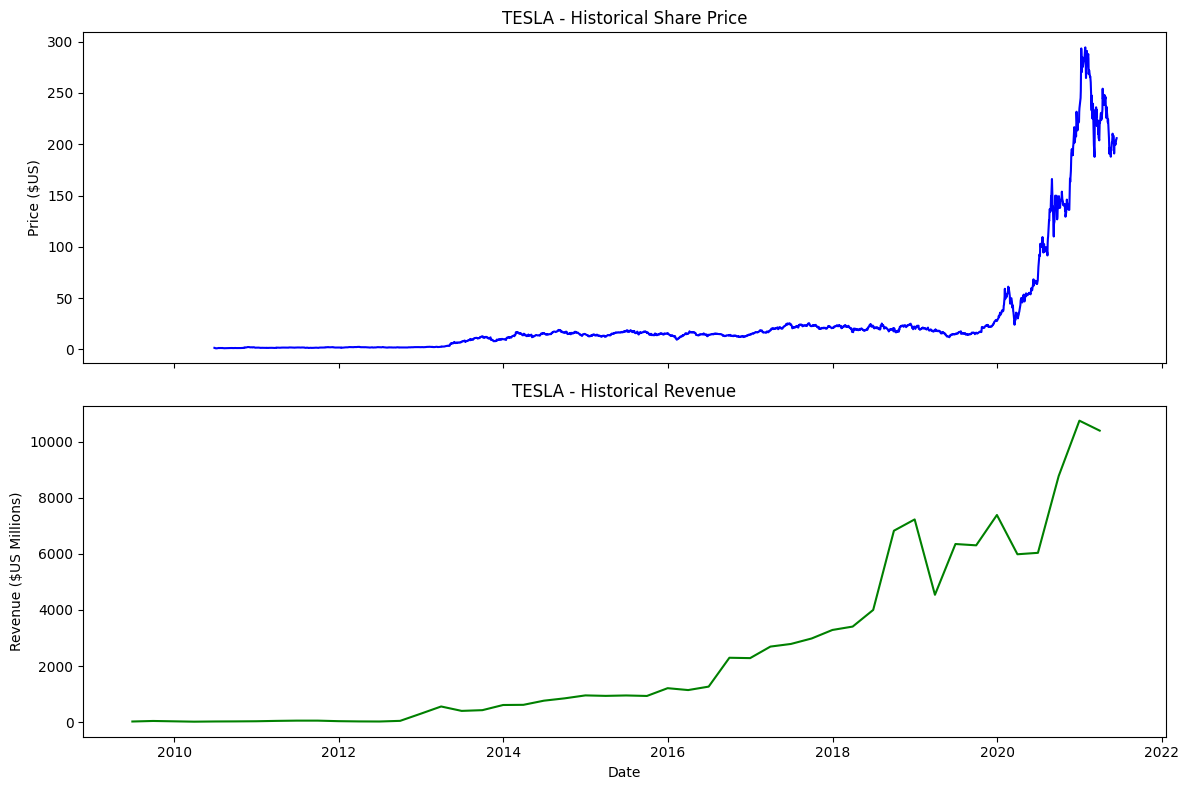

In [42]:
# Generación del gráfico final para Tesla
# Llamamos a la función personalizada 'make_graph' pasando:
# 1. tesla_data: El DataFrame con los precios históricos de la acción (vía yfinance).
# 2. tesla_revenue: El DataFrame con los ingresos históricos (vía web scraping).
# 3. 'TESLA': El nombre que se utilizará en los títulos de los gráficos.

# Nota: La función filtrará automáticamente las fechas hasta junio de 2021 para 
# asegurar una visualización clara y profesional del periodo analizado.
make_graph(tesla_data, tesla_revenue, 'TESLA')

<div>
    <h3>
        <span style="margin-right: 10px;">📝</span> Análisis de Resultados: Tesla
    </h3>
    <p>
        Al observar la comparativa entre el precio de la acción y los ingresos de Tesla, se pueden deducir los siguientes puntos:
    </p>
    <ul>
        <li>
            Existe una correlación visual clara entre el aumento sostenido de los ingresos (gráfica inferior) y la apreciación del precio de la acción, especialmente a partir de 2019-2020.
        </li>
        <li style="margin-top: 10px;">
            El precio de la acción tiende a subir de forma más agresiva que los ingresos, lo que indica que los inversores no solo valoran las ventas actuales, sino el potencial futuro y la innovación tecnológica de la empresa.
        </li>
        <li style="margin-top: 10px;">
            A pesar de fluctuaciones menores, la tendencia de ingresos trimestrales muestra una pendiente positiva constante, lo que respalda la solidez del modelo de negocio en el sector de vehículos eléctricos.
        </li>
    </ul>
</div>

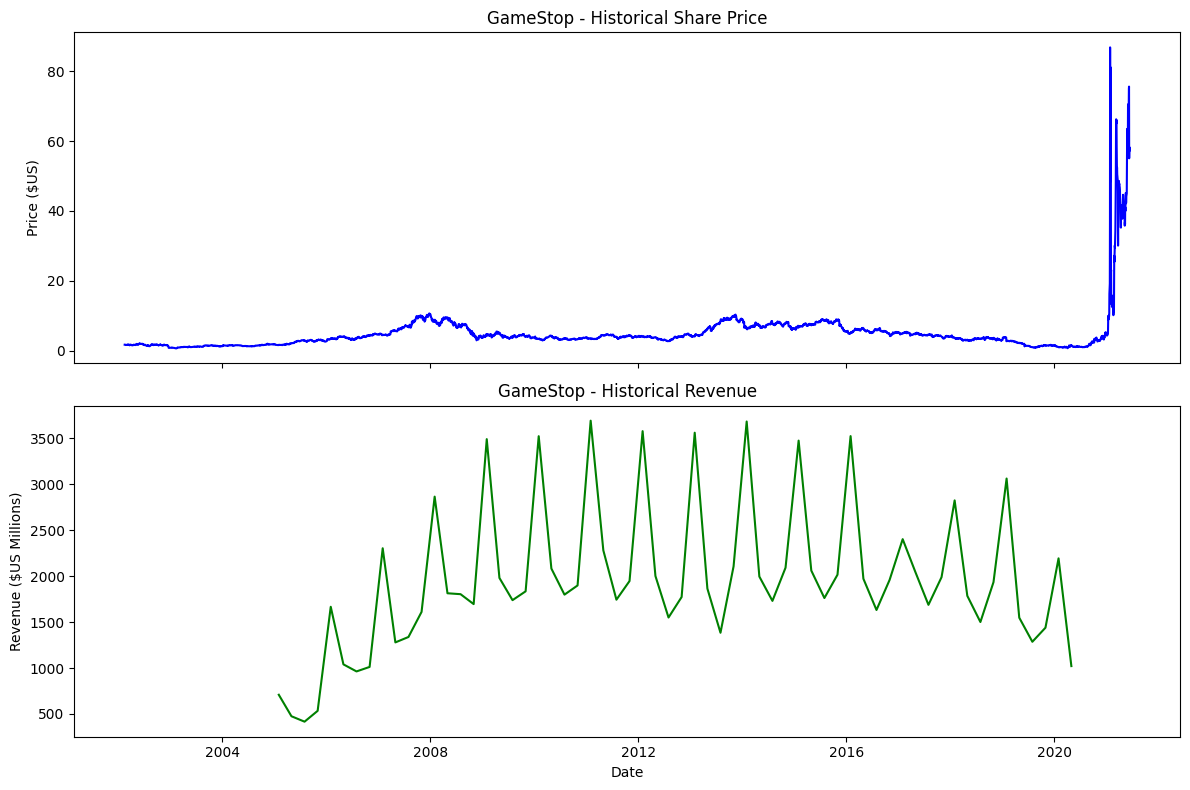

In [43]:
# Generación del gráfico final para GameStop (GME)
# Invocamos la función 'make_graph' utilizando los datos procesados:
# 1. gme_data: Historial de precios de la acción obtenido vía yfinance.
# 2. gme_revenue: Historial de ingresos (Revenue) extraído y limpiado del HTML.
# 3. 'GameStop': Título identificador para los ejes y leyendas del gráfico.

# Este gráfico es fundamental para observar eventos históricos como el "Short Squeeze" 
# de 2021 y comparar si el precio de la acción fue impulsado por ingresos reales 
# o por tendencias de mercado.
make_graph(gme_data, gme_revenue, 'GameStop')

<div>
    <h3>
        <span style="margin-right: 10px;">📝</span> Análisis de Resultados: GameStop
    </h3>
    <p>
        El caso de GameStop presenta un comportamiento radicalmente distinto al de Tesla, destacando los siguientes hallazgos:
    </p>
    <ul>
        <li>
            Se observa un pico masivo y repentino en el precio de la acción a principios de 2021 que <b>no coincide</b> con un aumento proporcional en los ingresos. Esto confirma visualmente el fenómeno del <i>Short Squeeze</i> impulsado por factores externos (comunidades de Reddit).
        </li>
        <li>
            La gráfica muestra picos cíclicos marcados (Q4), típicos del sector <i>retail</i> por la temporada de fiestas, aunque la tendencia general de ingresos no muestra un crecimiento a largo plazo.
        </li>
        <li>
            La gráfica demuestra que el precio de GME ha estado sujeto a una alta especulación, donde el valor de mercado se alejó significativamente de los fundamentos financieros (ventas reales).
        </li>
    </ul>
</div>